### N-Gram Analysis (Yoruba Text)

N-gram analysis is a basic yet powerful technique in Natural Language Processing (NLP). It involves breaking text into sequences of `n` items, usually words, to understand patterns, frequency, and co-occurrence. Examples include:
- **Unigram** (n=1): single words
- **Bigram** (n=2): pairs of words
- **Trigram** (n=3): triples of words
- ...and so on.

In this notebook, we’ll apply n-gram analysis to Yoruba-language text. We use the Yankari dataset (https://huggingface.co/datasets/acflp/YANKARI) as the reference corpus, extract n-grams of varying sizes, compute their probabilities, and use them to score new texts based on how likely they are under the model.

In [49]:
# import libraries
import json
import math
import regex as re
import unicodedata
from collections import Counter
from datasets import load_dataset
import pandas as pd
import os
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
# Load the reference corpus into a pandas DataFrame
dataset = load_dataset("acflp/YANKARI", verification_mode="basic_checks", trust_remote_code=True)

reference_text = pd.DataFrame(dataset["train"])[['text']]

# Display the first 5 rows of the DataFrame
print(reference_text.head())

                                                text
0  O ma ṣe o! Ijamba ọkọ ofurufu gba ẹmi eeyan ma...
1  Ọbasanjọ ni ki ijọba Naijiria lọ gba amọran lo...
2  Awọn ajinigbe ha ni Kwara, ọkan ku: Agbarijọ a...
3  AbdulRazaq san gbogbo gbese ti Gomina Ahmẹd jẹ...
4  Ọmọ ile igbimọ aṣoju-ṣofin tẹlẹ ni Kwara fẹgbẹ...



To build meaningful n-grams, we first **normalize** the text and **tokenize** it.


In [14]:
#Functions to preprocess and tokenize text
def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r"[^\p{L}\s'-]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_text(text):
    if isinstance(text, pd.Series) or isinstance(text, list):
        tokens = []
        for row in text:
            row = preprocess(row)
            tokens.extend(re.findall(r"\p{L}+(?:['-]\p{L}+)*", row))
        return tokens
    elif isinstance(text, str):
        text = preprocess(text)
        return re.findall(r"\p{L}+(?:['-]\p{L}+)*", text)
    else:
        return []

In [52]:
# Use the function to get all tokens from the reference text
all_tokens = tokenize_text(reference_text['text'])
print(f"Total tokens: {len(all_tokens)}")

Total tokens: 13586924


In the code block above, we create a variable to store all tokens from the reference corpus, apply preprocessing and tokenization, and print the total number of word tokens extracted.

We collected over **13 million tokens** after cleaning and tokenizing the text. These tokens form the basis for generating n-gram models (e.g., bigrams, trigrams) in later steps.


#### Building and Saving N-grams

To generate n-grams of different lengths (bigrams, trigrams, and 4-grams), we use the `build_ngrams()` function. It accepts the token list and a list of `n` values, and returns a dictionary mapping each `n` to its corresponding n-gram list.

In [53]:
#Functions to build n_grams
def build_ngrams(tokens, n_values=[2, 3, 4]):
    ngram_dict = {}
    for n in n_values:
        ngram_dict[n] = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    return ngram_dict

In [55]:
# Build n-grams for reference corpus
ref_dict = build_ngrams(all_tokens, n_values=[2, 3, 4])

for n, ngrams in ref_dict.items():
    print(f"Total {n}-grams: {len(ngrams)}")

Total 2-grams: 13586923
Total 3-grams: 13586922
Total 4-grams: 13586921


#### Computing N-gram Probabilities
We count the frequencies of the n-grams using Python’s `Counter`, and compute their probabilities.

The probability of each n-gram is calculated as:
$$
P(w_1, w_2, ..., w_n) = \frac{\text{count}(w_1, ..., w_n)}{\text{total number of n-grams}}
$$

After computing probabilities, we save each dictionary using Python’s `pickle` module. This allows for faster loading during evaluation, especially for large files.


In [56]:
# Compute n-gram probabilities
def compute_ngram_probs(ngram_dict):
    ngram_probs = {}
    for n, ngrams in ngram_dict.items():
        counter = Counter(ngrams)
        total = sum(counter.values())
        ngram_probs[n] = {ngram: count / total for ngram, count in counter.items()}
    return ngram_probs

# Probs for reference n-grams
ref_probs = compute_ngram_probs(ref_dict)

In [57]:
def save_ngram_probs(ngram_probs, base_file_path):
    for n in ngram_probs:
        with open(f"{base_file_path}ngram_{n}gram_probs.pkl", "wb") as f:
            pickle.dump(ngram_probs[n], f, protocol=pickle.HIGHEST_PROTOCOL)

save_ngram_probs(ref_probs, "C:/Users/DELL/Desktop/translation_evaluator/")

#### Scoring New Texts Using Log-Probability
Now, to evaluate how closely a new text matches the reference corpus & domain, we use n-gram log-probability scoring.

- Why Log Probabilities? When computing the probability of a sequence of n-grams, multiplying many small probabilities results in extremely tiny numbers. This leads to underflow issues. So, instead of multiplying, we use the log of each probability and sum them:
$$
\log P_{\text{total}} = \sum_{i=1}^{k} \log P(w_i, w_{i+1}, ..., w_{i+n-1})
$$

In [65]:
# Load the n-gram probs from the saved files
with open("C:/Users/DELL/Desktop/translation_evaluator/ngram_2gram_probs.pkl", "rb") as f:
    ngram_probs_2 = pickle.load(f)
with open("C:/Users/DELL/Desktop/translation_evaluator/ngram_3gram_probs.pkl", "rb") as f:
    ngram_probs_3 = pickle.load(f)
with open("C:/Users/DELL/Desktop/translation_evaluator/ngram_4gram_probs.pkl", "rb") as f:
    ngram_probs_4 = pickle.load(f)

In [58]:
# Function to compute log probabilities of n-grams
def compute_log_prob(n_grams, n_gram_probs, smoothing=1e-8):
    log_prob = 0.0
    for n_gram in n_grams:
        prob = n_gram_probs.get(n_gram, smoothing)
        log_prob += math.log(prob)
    return log_prob

In [70]:

# Function to get score and average score of new text.
def get_score(new_text, ngram_probs_dict, n_value, smoothing=1e-8):
    tokens = tokenize_text(new_text)
    ngrams = build_ngrams(tokens, n_values=[n_value])[n_value]
    log_prob_score = compute_log_prob(ngrams, ngram_probs_dict, smoothing)
    return log_prob_score

def get_avg_logprob(new_text, ngram_probs_dict, n_value, smoothing=1e-8):
    scores = []

    for doc in new_text:
        tokens = tokenize_text(doc)
        ngrams = build_ngrams(tokens, n_values=[n_value])[n_value]

        log_prob_score = compute_log_prob(ngrams, ngram_probs_dict, smoothing)
        
        # Append the average log probability score
        avg_log_prob = log_prob_score / len(ngrams)
        scores.append(avg_log_prob)

    return scores

#### How Does The Scoring Work
1. The new text is preprocessed and tokenized.
2. Its n-grams are generated **in memory**.
3. For each n-gram, we **look up its probability** in the reference model.
4. If an n-gram doesn’t exist, we use a small smoothing value. 
5. The log-probabilities are **summed** to give a final score.

### Interpreting the Score
- The log-probability is typically a **large negative number**.
- The **less negative** the score (i.e., closer to zero), the **more similar** the text is to the reference corpus.

In [72]:
rf_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/YANKARI.csv")["text"].dropna().tolist()[:30]

legal_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/Savor Yoruba (Legal Text).csv")["text"].dropna().tolist()

reli_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/AFC Elementary Lessons.csv")["Text"].dropna().tolist()

wura_text = pd.read_csv("C:/Users/DELL/Desktop/translation_evaluator/data/wura_yor.csv")["content"].dropna().tolist()[:30]


In [74]:
#Compute average log-probability for each document in rf_text
rf_scores = get_avg_logprob(rf_text, ngram_probs_4, n_value=4, smoothing=1e-8)
print(rf_scores[:5])

legal_scores = get_avg_logprob(legal_text, ngram_probs_4, n_value=4, smoothing=1e-8)
print(legal_scores[:5])

religious_scores = get_avg_logprob(reli_text, ngram_probs_4, n_value=4, smoothing=1e-8)
print(religious_scores[:5])

wura_scores = get_avg_logprob(wura_text, ngram_probs_4, n_value=4, smoothing=1e-8)
print(wura_scores[:5])

[-15.095437745711282, -15.716453774089896, -15.444663371174325, -15.572659856200149, -15.12478018767093]
[-17.44435123300824, -17.60026941783439, -18.09155708115181, -17.98903311552755, -18.106742781245465]
[-17.92497695591572, -17.8850456880212, -17.87397255978452, -17.830993495922634, -18.067864868001074]
[-16.01112446665552, -15.604941598970969, -14.882359228734654, -15.577821725111706, -15.774779803063517]


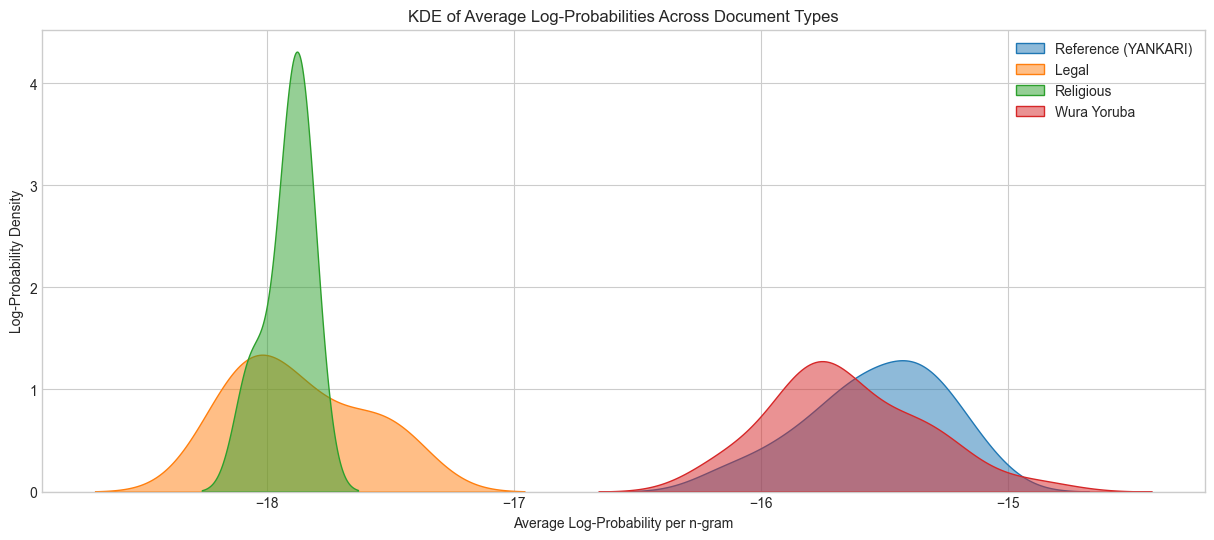

In [84]:
fig, ax = plt.subplots(figsize=(15, 6))

score_data = [
    (rf_scores, 'Reference (YANKARI)'),
    (legal_scores, 'Legal'),
    (religious_scores, 'Religious'),
    (wura_scores, 'Wura Yoruba'),
]
# Use a for loop to plot the score dat list
for scores, label in score_data:
    sns.kdeplot(scores, fill=True, label=label, alpha=0.5, ax=ax)

# Set labels and title
plt.xlabel('Average Log-Probability per n-gram')
plt.ylabel('Log-Probability Density')  # Y-axis label
plt.title('KDE of Average Log-Probabilities Across Document Types')

# Show plot
plt.legend()
plt.grid(True)  
plt.show()